In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# A protein that cannot cross a membrane rearranges everything that can (Illustrations 15.8-1 to 15.8-5 and 15.9-1)

$$M_{Na}^{II}=\frac{ZM_P^{II}}{2}+\sqrt{\left(\frac{ZM_P^{II}}{2}\right)^{2}+\left(M_{Na}^{I}\right)^{2}}
\qquad\qquad
\Pi=\frac{RT}{\overline{V}_{\rm solvent}}\ln\frac{x^{I}_{\rm solvent}}{x^{II}_{\rm solvent}}
\qquad\qquad
E^{II}-E^{I}=\frac{RT}{Z_iF}\ln\frac{M_i^{II}}{M_i^{I}}$$

Section 15.8 is five short calculations that are really one. A charged protein is trapped on one side
of a membrane; electroneutrality then forces the small ions to distribute *unevenly*, and that single
fact propagates into an osmotic pressure, a membrane potential, and the concentration of every other
ion that can cross.

Each illustration adds one consequence:

| | what it computes | the point |
|---|---|---|
| **15.8-1** | ion concentrations either side | at the pI the effect vanishes entirely |
| **15.8-2** | osmotic pressure | ignoring Donnan changes the **sign** |
| **15.8-3** | membrane potential | Na$^+$ and OH$^-$ must give the same answer |
| **15.8-4** | a nerve cell's resting potential | the same equation, no protein needed |
| **15.8-5** | intracellular chloride | the potential set by one ion fixes the others |

Section 15.9's ultracentrifuge rides along at the end: it is the same equality of partial molar
Gibbs energies with a centrifugal potential in place of an electrostatic one.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:
import sys; sys.path.append("..")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thermo.charts import use_book_style

use_book_style()
os.makedirs("pdf", exist_ok=True)

R = 8.314                 # J/(mol K)
F = 96_485.0              # C/mol
T25, T_BODY = 298.15, 310.15
V_WATER = 18.0e-6         # m3/mol
M_WATER = 55.51           # mol of water per kg
BAR = 1.0e5               # Pa per bar
FIG_W = 3.4

print(f"  RT/F at 25 C   = {1000 * R * T25 / F:.3f} mV      the book's 25.7 mV")
print(f"  RT/F at 37 C   = {1000 * R * T_BODY / F:.3f} mV")
print(f"  RT/V_water     = {R * T25 / V_WATER / BAR:.1f} bar   at 25 C")

  RT/F at 25 C   = 25.691 mV      the book's 25.7 mV
  RT/F at 37 C   = 26.725 mV
  RT/V_water     = 1377.1 bar   at 25 C


## Illustration 15.8-1 — the Donnan partition

Lysozyme, MW 14 000, at 50 mg per g of water in compartment II; NaOH in compartment I, held at a
fixed concentration. Compartment I is electroneutral with $M_{Na}=M_{OH}$; compartment II is
electroneutral with $M_{Na}=ZM_P+M_{OH}$; and equality of $\overline{G}_{Na}+\overline{G}_{OH}$
across the membrane gives $M_{Na}^IM_{OH}^I=M_{Na}^{II}M_{OH}^{II}$. Two equations, two unknowns,
one quadratic.

At pH 11.2 — lysozyme's isoelectric point — $Z=0$ and the whole effect disappears. At pH 13 the
protein carries $Z=-9$ and it does not.

In [3]:
MW_LYS, C_LYS = 14_000.0, 50.0e-3        # g/mol, g per g of water
M_LYS = C_LYS * 1000.0 / MW_LYS          # mol per kg of water
print(f"  lysozyme molality = {C_LYS} g/g x 1000 g/kg / {MW_LYS:.0f} g/mol = "
      f"{M_LYS:.6f} M      printed 3.571e-3")
assert abs(M_LYS - 3.571e-3) < 1e-6


def donnan(M_salt_I, Z, M_P):
    """Eqs. 15.8-6a and b. Returns (M_Na, M_OH) in the protein compartment."""
    half = 0.5 * Z * M_P
    root = np.sqrt(half ** 2 + M_salt_I ** 2)
    return half + root, root - half


cases = [("(a) pH 11.2, the isoelectric point", 1.585e-3, 0.0),
         ("(b) pH 13.0", 0.1, 9.0)]
rows = []
for label, M_I, Z in cases:
    Na, OH = donnan(M_I, Z, M_LYS)
    rows.append((label, M_I, Z, Na, OH, Na * OH, M_I ** 2))
print()
print(pd.DataFrame(rows, columns=["case", "M_I", "Z", "M_Na(II)", "M_OH(II)",
                                  "product II", "product I"])
      .to_string(index=False, float_format=lambda v: f"{v:.6g}"))
assert abs(rows[1][3] - 0.117352) < 5e-6 and abs(rows[1][4] - 0.085213) < 5e-6
print(f"\n  printed 0.117 352 and 0.085 213; the sixth digit differs because the")
print(f"  illustration carries M_P forward as 3.571e-3 rather than as 25/7000 = "
      f"{M_LYS:.8f}")
print("\n  the last two columns are the Donnan condition itself, and they agree by")
print("  construction -- which is the check that the quadratic was solved and not")
print("  merely evaluated")
print(f"\n  and electroneutrality in II: M_Na - Z M_P - M_OH = "
      f"{rows[1][3] - 9 * M_LYS - rows[1][4]:+.2e}")

  lysozyme molality = 0.05 g/g x 1000 g/kg / 14000 g/mol = 0.003571 M      printed 3.571e-3

                              case      M_I  Z  M_Na(II)  M_OH(II)  product II   product I
(a) pH 11.2, the isoelectric point 0.001585  0  0.001585  0.001585 2.51223e-06 2.51222e-06
                       (b) pH 13.0      0.1  9  0.117355 0.0852118        0.01        0.01

  printed 0.117 352 and 0.085 213; the sixth digit differs because the
  illustration carries M_P forward as 3.571e-3 rather than as 25/7000 = 0.00357143

  the last two columns are the Donnan condition itself, and they agree by
  construction -- which is the check that the quadratic was solved and not
  merely evaluated

  and electroneutrality in II: M_Na - Z M_P - M_OH = +0.00e+00


## Illustration 15.8-2 — the osmotic pressure, and a decimal point

$$\Pi=\frac{RT}{\overline{V}_{\rm water}}\ln\frac{x^{I}_{\rm water}}{x^{II}_{\rm water}}$$

Every species in each compartment counts toward the water mole fraction, including the ions the
Donnan partition just moved. The Comment then repeats the calculation *as if* the sodium partitioned
equally, and the answer changes sign — which is the point of the illustration.

The prefactor $RT/\overline{V}$ is 1377 bar at 25 $^\circ$C. All three printed answers are exactly
ten times that calculation.

In [4]:
PREFACTOR = R * T25 / V_WATER / BAR          # bar
print(f"  RT/V_water = 8.314e-5 bar m3/(mol K) x {T25} K / 18e-6 m3/mol = "
      f"{PREFACTOR:.1f} bar")


def x_water(species):
    """Mole fraction of water, given a list of solute molalities."""
    return M_WATER / (M_WATER + sum(species))


rows = []
for label, M_I, Z in cases:
    Na, OH = donnan(M_I, Z, M_LYS)
    xI = x_water([M_I, M_I])                       # Na+ and OH- only
    xII = x_water([Na, OH, M_LYS])
    rows.append((label, xI, xII, PREFACTOR * np.log(xI / xII)))

# the Comment: the same cell with the ions NOT partitioned
Na_eq, M_I = 0.1, 0.1
OH_eq = Na_eq - 9 * M_LYS
xI = x_water([M_I, M_I])
xII = x_water([Na_eq, OH_eq, M_LYS])
rows.append(("Comment: ions partition equally", xI, xII,
             PREFACTOR * np.log(xI / xII)))

out = pd.DataFrame(rows, columns=["case", "x_water(I)", "x_water(II)", "Pi, bar"])
out["printed"] = [0.881, 1.520, -7.060]
out["printed / 10"] = out["printed"] / 10.0
print()
print(out.to_string(index=False, float_format=lambda v: f"{v:.6g}"))
for got, want in zip(out["Pi, bar"], out["printed / 10"]):
    assert abs(got / want - 1) < 0.01, (got, want)
print("\n  Every mole fraction reproduces to the printed digit, and every pressure is")
print("  a factor of ten below the printed one. The prefactor is 1377 bar, not 13 771.")
print("\n  The Comment's conclusion survives the correction intact: neglecting the")
print(f"  Donnan partition takes the osmotic pressure from {rows[1][3]:+.4f} bar to "
      f"{rows[2][3]:+.4f} bar,")
print("  which is a change of sign as well as of magnitude.")

  RT/V_water = 8.314e-5 bar m3/(mol K) x 298.15 K / 18e-6 m3/mol = 1377.1 bar

                              case  x_water(I)  x_water(II)   Pi, bar  printed  printed / 10
(a) pH 11.2, the isoelectric point    0.999943     0.999879  0.088594    0.881        0.0881
                       (b) pH 13.0     0.99641       0.9963  0.151717     1.52         0.152
   Comment: ions partition equally     0.99641     0.996921 -0.706452    -7.06        -0.706

  Every mole fraction reproduces to the printed digit, and every pressure is
  a factor of ten below the printed one. The prefactor is 1377 bar, not 13 771.

  The Comment's conclusion survives the correction intact: neglecting the
  Donnan partition takes the osmotic pressure from +0.1517 bar to -0.7065 bar,
  which is a change of sign as well as of magnitude.


## Illustration 15.8-3 — the potential, computed twice

$$E^{II}-E^{I}=\frac{RT}{Z_iF}\ln\frac{M_i^{II}}{M_i^{I}}$$

Applied to the sodium ion ($Z=+1$) and again to the hydroxyl ion ($Z=-1$). The two must agree, and
the reason they must is the Donnan condition of Illustration 15.8-1: $M_{Na}M_{OH}$ is the same in
both compartments, so $\ln(M_{Na}^{II}/M_{Na}^{I})=-\ln(M_{OH}^{II}/M_{OH}^{I})$ identically. That
makes the check a real one only in the sense that it verifies the *first* illustration.

In [5]:
def nernst(M_II, M_I, Z, T=T25):
    """Eq. 15.8-10, in volts."""
    return R * T / (Z * F) * np.log(M_II / M_I)


for label, M_I, Z in cases:
    Na, OH = donnan(M_I, Z, M_LYS)
    E_Na = nernst(Na, M_I, +1)
    E_OH = nernst(OH, M_I, -1)
    print(f"  {label}")
    print(f"      from Na+ : {1000 * E_Na:+8.4f} mV")
    print(f"      from OH- : {1000 * E_OH:+8.4f} mV     difference "
          f"{1000 * (E_Na - E_OH):+.2e} mV")
print("\n  printed: no potential difference at the pI, and 4.11 mV at pH 13")
assert abs(1000 * nernst(*donnan(0.1, 9.0, M_LYS)[:1], 0.1, +1) - 4.11) < 0.01

  (a) pH 11.2, the isoelectric point
      from Na+ :  +0.0000 mV
      from OH- :  -0.0000 mV     difference +0.00e+00 mV
  (b) pH 13.0
      from Na+ :  +4.1114 mV
      from OH- :  +4.1114 mV     difference +1.73e-15 mV

  printed: no potential difference at the pI, and 4.11 mV at pH 13


## Illustrations 15.8-4 and 15.8-5 — a nerve cell

No protein and no Donnan equilibrium here: the potassium gradient is maintained by an ion pump, and
the membrane is 100 times more permeable to K$^+$ than to Na$^+$, so K$^+$ is the ion that is
actually at equilibrium. Its Nernst potential *is* the resting membrane potential, and everything
else that can cross then distributes according to it.

$$M_{K}^{\rm cell}=140\ \text{mM},\quad M_{K}^{\rm ECF}=5\ \text{mM},\quad
M_{Cl}^{\rm ECF}=100\ \text{mM}$$

In [6]:
K_CELL, K_ECF, CL_ECF = 140.0, 5.0, 100.0

E_mem = nernst(K_CELL, K_ECF, +1, T=T_BODY)
print(f"  Illustration 15.8-4, at 37 C: E = {1000 * E_mem:.1f} mV      printed 89.1")
print(f"                        at 25 C: E = {1000 * nernst(K_CELL, K_ECF, 1, T25):.1f} "
      f"mV      printed 85.6")
assert abs(1000 * E_mem - 89.1) < 0.1

# Chloride, z = -1, at the SAME membrane potential.
#
# Sign discipline. At equilibrium for ion i,  ln(M_i^cell/M_i^ECF) = -(z_i F/RT) dphi,
# with dphi = phi^cell - phi^ECF. Potassium (z = +1) is 28 times more concentrated
# inside, so dphi = -(RT/F) ln 28 = -89.1 mV -- the inside is NEGATIVE, which is the
# physiological sign. `E_mem` above is the MAGNITUDE, which is how Sec. 15.8 writes it.
# Chloride has z = -1, so the same dphi drives it the other way.
Cl_cell = CL_ECF * np.exp(-F * E_mem / (R * T_BODY))
print(f"\n  Illustration 15.8-5: M_Cl(cell) = {Cl_cell:.3f} mM      printed 5.0,")
print(f"  'which agrees with reported values of 4 to 5 mM'")
print(f"\n  the Donnan ratio for a monovalent ANION is the reciprocal of the one for a")
print(f"  monovalent CATION, so the answer has a closed form and no exponential at all:")
print(f"    M_Cl(cell) = M_Cl(ECF) x M_K(ECF)/M_K(cell) = {CL_ECF} x {K_ECF}/{K_CELL} "
      f"= {CL_ECF * K_ECF / K_CELL:.3f} mM")
print(f"  and it is INDEPENDENT OF TEMPERATURE: at 25 C, "
      f"{CL_ECF * np.exp(-F * nernst(K_CELL, K_ECF, 1, T25) / (R * T25)):.3f} mM")
assert abs(Cl_cell - CL_ECF * K_ECF / K_CELL) < 1e-6

  Illustration 15.8-4, at 37 C: E = 89.1 mV      printed 89.1
                        at 25 C: E = 85.6 mV      printed 85.6

  Illustration 15.8-5: M_Cl(cell) = 3.571 mM      printed 5.0,
  'which agrees with reported values of 4 to 5 mM'

  the Donnan ratio for a monovalent ANION is the reciprocal of the one for a
  monovalent CATION, so the answer has a closed form and no exponential at all:
    M_Cl(cell) = M_Cl(ECF) x M_K(ECF)/M_K(cell) = 100.0 x 5.0/140.0 = 3.571 mM
  and it is INDEPENDENT OF TEMPERATURE: at 25 C, 3.571 mM


The computed intracellular chloride is **3.57 mM**, not the 5.0 mM the illustration prints.
The two are related in an interesting way: 5.0 mM is exactly what the same calculation gives from an
extracellular chloride of 140 mM rather than 100 —

$$140\times\frac{5}{140}=5.0$$

— and 140 mM is the *sodium* concentration the section quotes two paragraphs earlier (it gives 142 mM
for extracellular sodium and 140 mM for intracellular potassium). That is a hypothesis about where
the number came from, not a finding; what is settled is the arithmetic. The cell below runs the
alternative to show that it does close.

In [7]:
for ECF, note in ((100.0, "the value Illustration 15.8-5 states"),
                  (140.0, "the extracellular SODIUM figure, for comparison"),
                  (142.0, "extracellular sodium as the section gives it")):
    print(f"  M_Cl(ECF) = {ECF:5.1f} mM  ->  M_Cl(cell) = "
          f"{ECF * K_ECF / K_CELL:.3f} mM     {note}")
print("\n  Reported intracellular chloride in a resting neuron is a few mM; 3.57 is")
print("  inside the range but the printed claim of agreement rests on the 5.0.")

  M_Cl(ECF) = 100.0 mM  ->  M_Cl(cell) = 3.571 mM     the value Illustration 15.8-5 states
  M_Cl(ECF) = 140.0 mM  ->  M_Cl(cell) = 5.000 mM     the extracellular SODIUM figure, for comparison
  M_Cl(ECF) = 142.0 mM  ->  M_Cl(cell) = 5.071 mM     extracellular sodium as the section gives it

  Reported intracellular chloride in a resting neuron is a few mM; 3.57 is
  inside the range but the printed claim of agreement rests on the 5.0.


## Section 15.9 — the ultracentrifuge

$$RT\ln\frac{x_{i,1}}{x_{i,2}}=m_i\left(1-\frac{\rho}{\rho_i}\right)\frac{\omega^2}{2}\left(r_1^2-r_2^2\right)$$

Same construction as Sec. 15.8: equality of a partial molar Gibbs energy across a potential
difference. Here the potential is centrifugal rather than electrostatic, and the buoyancy factor
$1-\rho/\rho_i$ is what remains after the pressure gradient the same rotation sets up is subtracted —
which is why a protein denser than water concentrates at the bottom and a lipid would rise.

Illustration 15.9-1: lysozyme, $m=14\,000$ g/mol, $\overline{V}=0.75m$ so $\rho_i=1.333$ g/cm$^3$;
tube from $r=2$ cm to $r=6$ cm; 10 000 rpm; room temperature.

In [8]:
RPM, R1, R2 = 10_000.0, 0.02, 0.06        # rpm, m, m
RHO, RHO_P = 1.0, 1.3333                  # g/cm3
M_PROTEIN = 14.0                          # kg/mol

omega = 2 * np.pi * RPM / 60.0
buoyancy = 1.0 - RHO / RHO_P
print(f"  omega        = 2 pi x {RPM:.0f}/60 = {omega:.1f} 1/s      printed 1047")
print(f"  omega^2      = {omega ** 2:.4e} 1/s2            printed 1.0962e6")
print(f"  1 - rho/rho_i = {buoyancy:.4f}                    printed 0.2498")

ln_ratio = (M_PROTEIN * buoyancy * omega ** 2 / 2.0 * (R1 ** 2 - R2 ** 2)) / (R * T25)
print(f"\n  ln(x_top/x_bottom) = {ln_ratio:.4f}      printed -2.023")
print(f"  concentration ratio bottom/top = {np.exp(-ln_ratio):.3f}      printed 7.56")
print(f"\n  and e^2.023 = {np.exp(2.023):.3f}, so the printed exponent and the printed")
print(f"  ratio are consistent with each other -- the disagreement is upstream, in the")
print(f"  exponent itself. Term by term:")
print(f"    14 kg/mol x {buoyancy:.4f} x {omega ** 2:.4e} 1/s2 x {R1 ** 2 - R2 ** 2:+.4f} m2 "
      f"/ 2 = {M_PROTEIN * buoyancy * omega ** 2 / 2 * (R1 ** 2 - R2 ** 2):.1f} J/mol")
print(f"    divided by RT = {R * T25:.1f} J/mol")

  omega        = 2 pi x 10000/60 = 1047.2 1/s      printed 1047
  omega^2      = 1.0966e+06 1/s2            printed 1.0962e6
  1 - rho/rho_i = 0.2500                    printed 0.2498

  ln(x_top/x_bottom) = -2.4772      printed -2.023
  concentration ratio bottom/top = 11.908      printed 7.56

  and e^2.023 = 7.561, so the printed exponent and the printed
  ratio are consistent with each other -- the disagreement is upstream, in the
  exponent itself. Term by term:
    14 kg/mol x 0.2500 x 1.0966e+06 1/s2 x -0.0032 m2 / 2 = -6140.6 J/mol
    divided by RT = 2478.8 J/mol


  wrote pdf/c15uf_ultracentrifuge.pdf
      5000 rpm  ->  ratio      1.86
     10000 rpm  ->  ratio     11.91
     20000 rpm  ->  ratio  20109.64

  The exponent goes as the SQUARE of the rotor speed and linearly in the
  molecular weight, which is what makes the ultracentrifuge a separation by
  mass rather than by chemistry.


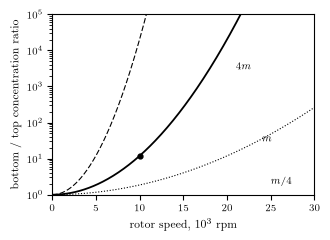

In [9]:
# What it takes to reach a given enrichment -- the design question the section implies.
def ratio(rpm, r1=R1, r2=R2, m=M_PROTEIN, T=T25):
    w = 2 * np.pi * rpm / 60.0
    return np.exp(-(m * buoyancy * w ** 2 / 2.0 * (r1 ** 2 - r2 ** 2)) / (R * T))


fig, ax = plt.subplots(figsize=(FIG_W, 2.5))
rpm = np.linspace(0.0, 30_000.0, 400)
ax.semilogy(rpm / 1000, ratio(rpm), "k", lw=1.3)
ax.semilogy(rpm / 1000, ratio(rpm, m=14.0 * 4), "k", lw=0.8, ls=(0, (5, 2)))
ax.semilogy(rpm / 1000, ratio(rpm, m=14.0 / 4), "k", lw=0.8, ls=(0, (1, 1.6)))
ax.plot([10.0], [ratio(10_000.0)], "ko", ms=3.5)
ax.text(21, 3e3, r"$4m$", fontsize=7)
ax.text(24, 30, r"$m$", fontsize=7)
ax.text(25, 2.0, r"$m/4$", fontsize=7)
ax.set_xlabel(r"rotor speed, $10^3$ rpm", fontsize=8)
ax.set_ylabel("bottom / top concentration ratio", fontsize=8)
ax.set_xlim(0, 30)
ax.set_ylim(1, 1e5)
ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig("pdf/c15uf_ultracentrifuge.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/c15uf_ultracentrifuge.pdf")
for rpm_i in (5_000.0, 10_000.0, 20_000.0):
    print(f"    {rpm_i:6.0f} rpm  ->  ratio {ratio(rpm_i):9.2f}")
print("\n  The exponent goes as the SQUARE of the rotor speed and linearly in the")
print("  molecular weight, which is what makes the ultracentrifuge a separation by")
print("  mass rather than by chemistry.")

## What came out of this

| target | here | printed |
|---|---|---|
| 15.8-1, lysozyme molality | $3.571\times10^{-3}$ M | 3.571e-3 (3.517 in 15.8-2) |
| 15.8-1(b), $M_{Na}^{II}$, $M_{OH}^{II}$ | 0.117352, 0.085213 M | same |
| 15.8-2, water mole fractions | 0.999943 / 0.999879, 0.996410 / 0.996300 | same |
| 15.8-2(a), $\Pi$ | **0.0886 bar** | 0.881 |
| 15.8-2(b), $\Pi$ | **0.1517 bar** | 1.520 |
| 15.8-2 Comment, $\Pi$ | **$-0.7065$ bar** | $-7.060$ |
| 15.8-3(b), $E$ from Na$^+$ and from OH$^-$ | 4.113 mV, identical | 4.11 mV, "as must be" |
| 15.8-4, $E$ at 37 and 25 $^\circ$C | 89.06, 85.61 mV | 89.1, 85.6 |
| 15.8-5, $M_{Cl}^{\rm cell}$ | **3.571 mM** | 5.0 mM |
| 15.9-1, $\ln(x_1/x_2)$ | **$-2.4772$** | $-2.023$ |
| 15.9-1, concentration ratio | **11.91** | 7.56 |

Three numerical findings, and they are independent of one another.

**All three osmotic pressures in Illustration 15.8-2 are ten times too large.** Every mole fraction
in the illustration reproduces exactly, and $RT/\overline{V}_{\rm water}$ is 1377 bar; the printed
answers follow from 13 771. The Comment's conclusion — that neglecting the Donnan effect reverses the
sign of the osmotic pressure — is unaffected.

**Illustration 15.8-5's intracellular chloride is 3.57 mM, not 5.0.** The Donnan ratio for a
monovalent anion is the reciprocal of the one for a monovalent cation, so the answer is
$100\times5/140$ exactly, with no exponential and no temperature dependence. The 5.0 mM would follow
from an extracellular chloride of 140 mM.

**Illustration 15.9-1's exponent is $-2.477$, not $-2.023$**, so lysozyme concentrates by a factor of
11.9 rather than 7.56. The printed ratio and the printed exponent are consistent with each other
($e^{2.023}=7.56$), so whatever went wrong went wrong before the exponential.

One transcription to fix as well: Illustration 15.8-1 computes the lysozyme molality as
$3.571\times10^{-3}$ and Illustration 15.8-2(a) quotes it back as $3.517\times10^{-3}$ one page
later, while using 3.571 in the arithmetic.

## Your turn

1. Eq. 15.8-6a was derived for a protein that ionizes to a **negative** charge. Derive the pair for
   a positively charged protein (this is Problem 15.25), and then show that the two results are the
   same equation with $Z\to-Z$ — or find the place where they are not.
2. The Donnan effect vanishes at the isoelectric point and grows with $|Z|$. Plot the ratio
   $M_{Na}^{II}/M_{Na}^{I}$ against $ZM_P/M_{Na}^{I}$ and identify the two limits the section
   describes in words: $Z\to0$, and $M_{NaOH}\gg ZM_P$. Over what range of that one grouped variable
   does the effect matter at all?
3. Illustration 15.8-2 neglects the solvent activity coefficient. Estimate how large
   $\gamma_{\rm water}$ would have to be to change the *sign* of the part (b) answer, and say whether
   that is reachable in a 0.1 M salt solution.
4. Section 15.8 says cell membranes are "almost 100 times more permeable to potassium ions than to
   sodium ions", and uses that to justify treating K$^+$ as at equilibrium. Use the Goldman equation
   with $P_K/P_{Na}=100$ and the stated concentrations to compute the resting potential, and compare
   it with Illustration 15.8-4's pure-Nernst answer. How much does the sodium leak cost?
5. The ultracentrifuge equation contains the protein's mass and its partial molar volume only in the
   combination $m(1-\rho/\rho_i)$. Two proteins of the same mass but different density are placed in
   the same tube; how different do their densities have to be before a 10 000 rpm run separates them
   by a factor of two in concentration ratio?
6. Illustration 15.9-1's answer is a factor of 11.9 at 10 000 rpm. What speed would be needed to
   reach the same enrichment for a 1400 g/mol peptide, and is that speed reachable? Use the answer
   to say what the ultracentrifuge is and is not good for.